<a href="https://colab.research.google.com/github/channel1umut-lang/Deep-Learning/blob/main/0008_PyTorchTrainingStructural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [ ]:
# get data ready
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DL Datasets/06-study_hours_grades.csv")

In [ ]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [ ]:
X = torch.tensor(df['study_hours'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['grade'].values, dtype=torch.float32).unsqueeze(1)

# we do this because we are going to use nn.Linear which expects float32 rather than other dtype in its weights
# also it expects 2D inputs when using nn.Linear. (batch_size, in_features) and if do not unsquueze it, it won't have that dimension
# just do it without unsquueze and see what happens in the training loop?

In [ ]:
X

tensor([[3.7454],
        [9.5071],
        [7.3199],
        [5.9866],
        [1.5602],
        [1.5599],
        [0.5808],
        [8.6618],
        [6.0111],
        [7.0807],
        [0.2058],
        [9.6991],
        [8.3244],
        [2.1234],
        [1.8182],
        [1.8340],
        [3.0424],
        [5.2476],
        [4.3195],
        [2.9123],
        [6.1185],
        [1.3949],
        [2.9214],
        [3.6636],
        [4.5607],
        [7.8518],
        [1.9967],
        [5.1423],
        [5.9241],
        [0.4645],
        [6.0754],
        [1.7052],
        [0.6505],
        [9.4889],
        [9.6563],
        [8.0840],
        [3.0461],
        [0.9767],
        [6.8423],
        [4.4015],
        [1.2204],
        [4.9518],
        [0.3439],
        [9.0932],
        [2.5878],
        [6.6252],
        [3.1171],
        [5.2007],
        [5.4671],
        [1.8485]])

In [ ]:
y

tensor([[30.2039],
        [57.8785],
        [46.3684],
        [39.3307],
        [14.8439],
        [16.3600],
        [11.9829],
        [55.4230],
        [40.7430],
        [41.8775],
        [11.6774],
        [57.7253],
        [50.2683],
        [21.8403],
        [21.1532],
        [21.0328],
        [23.5337],
        [35.6194],
        [32.2598],
        [26.5125],
        [39.6343],
        [16.6034],
        [22.3946],
        [25.9257],
        [34.4286],
        [51.9713],
        [19.8397],
        [37.7188],
        [40.3440],
        [11.0323],
        [41.1000],
        [21.6023],
        [13.1809],
        [60.5736],
        [53.0421],
        [52.0637],
        [25.4048],
        [14.2856],
        [44.3952],
        [28.0325],
        [15.6626],
        [35.4731],
        [14.6752],
        [54.4295],
        [21.3220],
        [42.1226],
        [27.4164],
        [36.6609],
        [36.2760],
        [20.2693]])

In [ ]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [ ]:
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

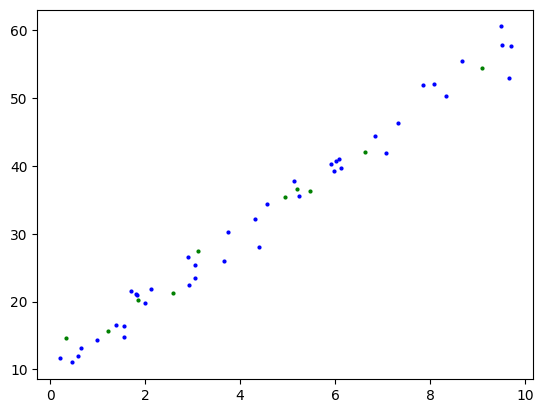

In [ ]:
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.show()

In [ ]:
import torch.nn as nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, # We are setting up how many neuron that we are going to add. in_features = amount of the input number.
                                      out_features=1) # amount of the output from that neuron

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # Girdi tensörünü (x) doğrusal (lineer) katmandan geçir
        return self.linear_layer(x) # Çıktı: x'in ağırlık matrisi ile çarpılıp bias eklenmiş hali

# in models we will learn how to make it multiple layers, add activation functions etc in upcoming sections
# we are now making a very simple regression using nn.Linear. if i have that kind of data in real life, i'd use sklearn and solve this with ml simply
# however we are still practicing anns in the most simplified way.

In [ ]:
torch.manual_seed(42)
model = LinearRegressionModel()
model = torch.compile(model)

In [ ]:
model

OptimizedModule(
  (_orig_mod): LinearRegressionModel(
    (linear_layer): Linear(in_features=1, out_features=1, bias=True)
  )
)

In [ ]:
model.state_dict()

OrderedDict([('_orig_mod.linear_layer.weight', tensor([[0.7645]])),
             ('_orig_mod.linear_layer.bias', tensor([0.8300]))])

In [ ]:
#nn.Linear() layer created a random weight and bias parameter for us

In [ ]:
# let's create the optimizer and loss function again

In [ ]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

In [ ]:
epochs = 120

for epoch in range(epochs):

    model.train()

    # 1. Forward pass
    y_pred = model(X_train)

    # 2. loss calculation
    loss = loss_fn(y_pred, y_train)

    # 3. reset optimizer
    optimizer.zero_grad()

    # 4. backward prop
    loss.backward()

    # 5. optimize the weights
    optimizer.step()

    # Test steps
    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        # 2. test loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 5 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 965.6339721679688 | Test loss: 160.62022399902344
Epoch: 5 | Train loss: 22.257577896118164 | Test loss: 27.251602172851562
Epoch: 10 | Train loss: 21.13695526123047 | Test loss: 25.89261245727539
Epoch: 15 | Train loss: 20.168928146362305 | Test loss: 24.743696212768555
Epoch: 20 | Train loss: 19.254438400268555 | Test loss: 23.6547908782959
Epoch: 25 | Train loss: 18.390506744384766 | Test loss: 22.621475219726562
Epoch: 30 | Train loss: 17.574350357055664 | Test loss: 21.640789031982422
Epoch: 35 | Train loss: 16.803316116333008 | Test loss: 20.709945678710938
Epoch: 40 | Train loss: 16.07491683959961 | Test loss: 19.826316833496094
Epoch: 45 | Train loss: 15.386789321899414 | Test loss: 18.987407684326172
Epoch: 50 | Train loss: 14.736712455749512 | Test loss: 18.190872192382812
Epoch: 55 | Train loss: 14.122581481933594 | Test loss: 17.434463500976562
Epoch: 60 | Train loss: 13.54240608215332 | Test loss: 16.716089248657227
Epoch: 65 | Train loss: 12.9943037

In [ ]:
print(model.state_dict())

OrderedDict({'_orig_mod.linear_layer.weight': tensor([[5.6578]]), '_orig_mod.linear_layer.bias': tensor([5.7629])})


In [ ]:
# let's make a prediction

In [ ]:
model.eval()
with torch.inference_mode():
  y_preds = model(X_test)

In [ ]:
y_test

tensor([[15.6626],
        [35.4731],
        [14.6752],
        [54.4295],
        [21.3220],
        [42.1226],
        [27.4164],
        [36.6609],
        [36.2760],
        [20.2693]])

In [ ]:
y_preds

tensor([[12.6677],
        [33.7793],
        [ 7.7086],
        [57.2109],
        [20.4043],
        [43.2474],
        [23.3991],
        [35.1876],
        [36.6950],
        [16.2217]])

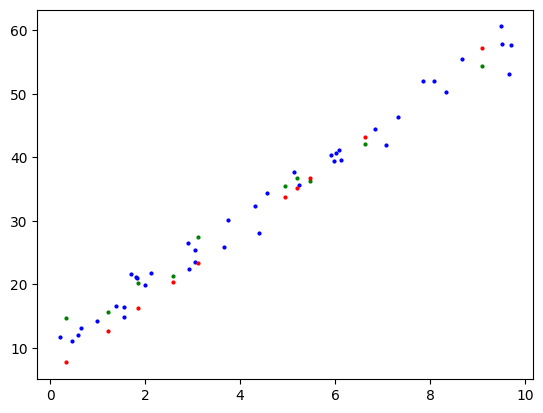

In [ ]:
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.scatter(X_test, y_preds, c="r", s=4, label="Predictions")
plt.show()